In [38]:
start_year = "2020"
days_holding = "7"
days_momentum = "30"
min_mcap = "0"
long_decile = "9"
short_decile = "-1"
max_longs = "20"
max_shorts = "0"

In [39]:
start_year_P = int(start_year)
days_holding_P = int(days_holding)
days_momentum_P = int(days_momentum)
min_mcap_P = float(min_mcap)
long_decile_P = int(long_decile)
short_decile_P = int(short_decile)
max_longs_P = int(max_longs)
max_shorts_P = int(max_shorts)

print(
    f"""
start_year: {start_year_P}
holding_days: {days_holding_P}
momentum_days: {days_momentum_P}
min_mcap: {min_mcap_P}
long_decile: {long_decile_P}
short_decile: {short_decile_P}
max_longs: {max_longs_P}
max_shorts: {max_shorts_P}
"""
)


start_year: 2020
holding_days: 7
momentum_days: 30
min_mcap: 0.0
long_decile: 9
short_decile: -1
max_longs: 20
max_shorts: 0



In [40]:
import datetime as dt
import polars as pl
import scrapbook as sb
import backtest as bt

stables = [
    "bfusd",
    "busd",
    "dai",
    "fdusd",
    "rlusd",
    "susd",
    "tusd",
    "usd1",
    "usdc",
    "usde",
    "usdp",
    "usds",
    "usdsb",
    "xusd",
]


df = (
    pl.read_parquet("cmc-usd-1d-2020-2026.parquet")
    .unique(subset=["symbol", "ts"])
    .sort(["symbol", "ts"])
    .filter(~pl.col("symbol").is_in(stables))
    .with_columns(mom=pl.col("close").pct_change(days_momentum_P).over("symbol"))
    .filter(pl.col("ts").dt.year() >= start_year_P)
    .drop_nulls(["mom", "close", "volume"])
    .with_columns(
        decile=pl.col("mom")
        .qcut(10, labels=[str(i) for i in range(10)], allow_duplicates=True)
        .over("ts")
        .cast(pl.Utf8)
        .cast(pl.Int8)
    )
    .sort("ts")
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2288/2288 [00:10<00:00, 216.32it/s]


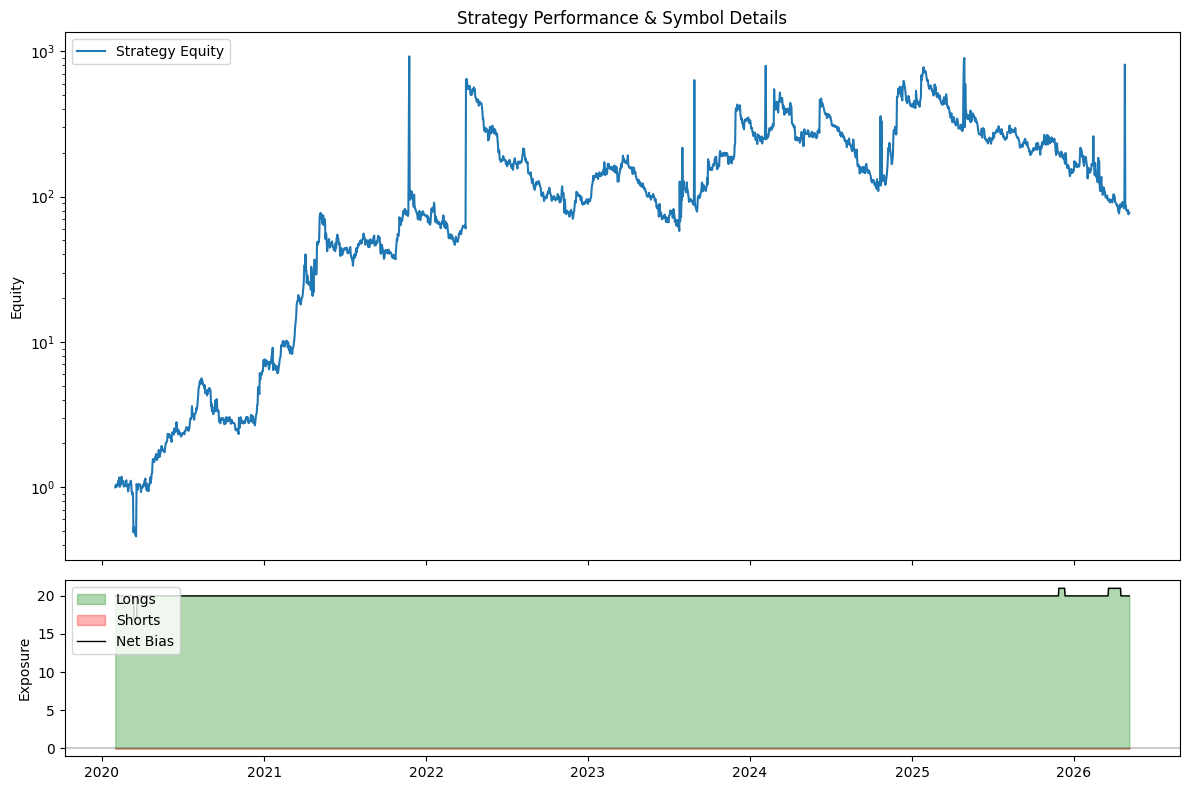

mfe_std: 1710.4397


ann_std: 5.0501 (0.0000)


mae: -0.2746


ann_return: 5.4351 (0.0000)


maxdd: -0.8456


...

mfe: 61.7220


ir: 1.0749


win_rate: 0.4979


mae_std: 0.2272


kelly: 0.2131
half_kelly: 0.1066


In [41]:
class Alpha(bt.AlphaModel):
    def __init__(self, long_expr: pl.Expr, short_expr: pl.Expr):
        self.long_expr = long_expr
        self.short_expr = short_expr

    def __call__(self, df: pl.DataFrame) -> list[bt.Signal]:
        today = df["ts"].max()
        dfnow = df.filter(pl.col("ts") == today)

        l = dfnow.filter(self.long_expr).sort("mom", descending=True)
        s = dfnow.filter(self.short_expr).sort("mom", descending=False)

        return [bt.Signal(r["symbol"], True, 1.0) for r in l.iter_rows(named=True)][
            :max_longs_P
        ] + [bt.Signal(r["symbol"], False, 1.0) for r in s.iter_rows(named=True)][
            :max_shorts_P
        ]


# Setup conditional gating for optional long/short logic
if long_decile_P == -1:
    long_expr = pl.lit(False)
else:
    long_expr = (
        (pl.col("decile") >= long_decile_P)
        & (pl.col("mom") > 0)
        & (pl.col("market_cap") >= min_mcap_P)
    )


if short_decile_P == -1:
    short_expr = pl.lit(False)
else:
    short_expr = (
        (pl.col("decile") <= short_decile_P)
        & (pl.col("mom") < 0)
        & (pl.col("market_cap") >= min_mcap_P)
    )

test = bt.Backtest(
    df,
    alpha=Alpha(long_expr=long_expr, short_expr=short_expr),
    portfolio=bt.EqualWeight(),
    # portfolio=bt.VolumeWeighted(price_col="price", symbol_col="symbol", volume_col='total_volume'),
    #risk=bt.MaxDrawdown(
    #    absolute=0.2,
    #    trailing=0.1,
    #),
    period=days_holding_P,
    eager_rebalance=False,
    benchmark="btc",
)

test.run(initial_equity=1.0)

res = test.report(plot="brief")


def _fmt(v):
    return f"{v:.4f}" if v is not None else "N/A"


if not res.is_empty():
    for col in set(res.columns) - {"year", "src"}:
        s_df = res.filter(pl.col("src") == "Strategy")
        b_df = res.filter(pl.col("src") == "Benchmark")

        s_val = s_df[col].mean()
        b_val = b_df[col].mean() if not b_df.is_empty() else None

        if b_val is not None:
            print(f"{col}: {_fmt(s_val)} ({_fmt(b_val)})")
        else:
            print(f"{col}: {_fmt(s_val)}")

        if s_val is not None:
            sb.glue(col, float(s_val))

    # Kelly fraction: f* = ann_return / (ann_std²)
    s_ret = s_df["ann_return"].mean()
    s_std = s_df["ann_std"].mean()
    if s_ret is not None and s_std is not None and s_std > 0:
        kelly = s_ret / (s_std**2)
        half_kelly = kelly / 2
        print(f"kelly: {_fmt(kelly)}")
        print(f"half_kelly: {_fmt(half_kelly)}")
        sb.glue("kelly", float(kelly))
        sb.glue("half_kelly", float(half_kelly))
    else:
        print("kelly: N/A")
        print("half_kelly: N/A")
else:
    print("No trades executed.")

In [18]:
folio = test.live(equity=10_000)

In [19]:
import gecko
from coingecko_sdk import AsyncCoingecko
import os
from jinja2 import Template

async with AsyncCoingecko(
    demo_api_key=os.environ.get("COINGECKO_API_KEY"),
    environment="demo",
) as client:
    summaries = await gecko.summary(
        client, folio["symbol"].to_list(), 90, gecko.exchange_whitelist
    )

  0%|                                                                                                                                              | 0/3 [00:00<?, ?it/s][14:33:10] INFO    HTTP Request: GET https://api.coingecko.com/api/v3/coins/terra-luna/tickers "HTTP/1.1 200 OK"
[14:33:10] INFO    HTTP Request: GET https://api.coingecko.com/api/v3/coins/dash/tickers "HTTP/1.1 200 OK"
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  5.65it/s]


In [20]:
from IPython.display import display, HTML
import datetime as dt
import humanize
from jinja2 import Template

ts = folio["entry_ts"].max()
age = dt.datetime.now() - ts
stale = age > dt.timedelta(hours=4)

tmpl = """
{% macro fmtnum(value) -%}
    {%- if value == 0 -%}
        0.00
    {%- elif value >= 1 -%}
        {{ "{:,.4f}".format(value) }}
    {%- else -%}
        {# Rule: Find where the significant decimals start #}
        {# We format to 12 places to be safe, then find the first non-zero after '0.' #}
        {% set long_val = "{:.12f}".format(value) %}
        {% set decimal_part = long_val.split('.')[1] %}
        
        {# Loop to find the index of the first non-zero digit #}
        {% set ns = namespace(found=false, index=0) %}
        {% for char in decimal_part %}
            {% if not ns.found %}
                {% if char != '0' %}
                    {% set ns.found = true %}
                {% else %}
                    {% set ns.index = ns.index + 1 %}
                {% endif %}
            {% endif %}
        {% endfor %}
        
        {# Precision = leading zeros + 6 significant digits #}
        {% set precision = ns.index + 6 %}
        {{ "{:.{}f}".format(value, precision).rstrip('0').rstrip('.') }}
        
    {%- endif -%}
{%- endmacro %}

<h1>{{ portfolio_date }}</h1>

{% if is_stale %}
    <span style="font-size: 120%; color: red">Data is from {{ data_age }} ago and stale!</span>
{% endif %}

<section>
{% for pos in portfolio %}
    <div style="padding-top: 10px">
        <div>
            <b>{{ pos.symbol | upper }}</b>
            BTO {{ fmtnum(pos.shares) }} @ {{ fmtnum(pos.entry_price) }}
        </div>
        
        <table>
            <tr><th>Market</th><th>Volume</th></tr>
            {% for m in summaries[pos.symbol].markets %}
            <tr>
                <td><a href="#">{{ m.name }}</a></td>
                <td>{{ m.volume }}</td>
            </tr>
            {% endfor %}
        </table>
    </div>
{% endfor %}
</section>
"""

display(
    HTML(
        Template(tmpl).render(
            portfolio_date=ts.date(),
            data_age=humanize.precisedelta(age, minimum_unit="hours"),
            is_stale=stale,
            portfolio=folio.iter_rows(named=True),
            summaries=summaries,
        )
    )
)

TypeError: can't subtract offset-naive and offset-aware datetimes

In [ ]:
import matplotlib.pyplot as plt
import io
import base64
from jinja2 import Template
from IPython.display import display, HTML

import polars as pl
import matplotlib.pyplot as plt
import io
import base64


def plot_ohlc_base64(df: pl.DataFrame, figsize=(3, 1.5)):
    """
    Takes a Polars DataFrame with columns ['ts', 'open', 'high', 'low', 'close']
    and returns a base64 encoded string of the matplotlib candlestick chart.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Extract data to numpy arrays for fast matplotlib plotting
    # Assuming the dataframe is already sorted by 'ts'
    x = range(len(df))
    opens = df["open"].to_numpy()
    highs = df["high"].to_numpy()
    lows = df["low"].to_numpy()
    closes = df["close"].to_numpy()

    # Determine colors: Green (#10b981) for Up days, Red (#ef4444) for Down days
    colors = ["#10b981" if c >= o else "#ef4444" for o, c in zip(opens, closes)]

    # 1. Plot the wicks (high to low)
    ax.vlines(x, ymin=lows, ymax=highs, color=colors, linewidth=1)

    # 2. Plot the bodies (open to close)
    body_bottom = [min(o, c) for o, c in zip(opens, closes)]
    body_top = [max(o, c) for o, c in zip(opens, closes)]

    # Give dojis (open == close) a tiny visual height so they show up
    y_range = max(highs) - min(lows) if len(highs) > 0 else 1
    min_height = y_range * 0.005
    body_top = [max(t, b + min_height) for t, b in zip(body_top, body_bottom)]

    # Draw bodies using thicker vlines
    ax.vlines(x, ymin=body_bottom, ymax=body_top, color=colors, linewidth=4)

    # Hide axes to act as a sparkline widget
    ax.axis("off")

    # Save to buffer with a transparent background
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", transparent=True, dpi=100)
    plt.close(fig)

    return base64.b64encode(buf.getvalue()).decode("utf-8")


positions_html = ""
for sym, summ in summaries.items():
    positions_html += f"""
    <div class="bg-slate-900 rounded-xl p-3 border border-slate-800 shadow-lg flex flex-col">
        <div class="flex justify-between items-start mb-2">
            <div>
                <h3 class="text-base font-bold text-slate-100">{sym.upper()}</h3>
                <div class="flex flex-wrap gap-1 mt-1.5">
                    <span class="text-[9px] font-semibold bg-slate-700/80 text-slate-300 px-1.5 py-0.5 rounded border border-slate-600">MKT</span>
                </div>
            </div>
            <div class="text-right">
                <div class="text-sm font-mono text-emerald-400 font-semibold">$100.00</div>
            </div>
        </div>
        <img src="data:image/png;base64,{plot_ohlc_base64(summ.prices, figsize=(3, 1.5))}" class="w-full h-[120px] object-contain mt-auto" />
    </div>
    """

# Load, render, and display
with open("dashboard.html", "r") as f:
    template = Template(f.read())

display(
    HTML(
        template.render(
            latest_date="May 7, 2026",
            ytd_return="+28.4%",
            equity_img_base64=get_mock_base64((10, 3), "#10b981"),
            positions_html=positions_html,
        )
    )
)

In [ ]:
from IPython.display import display, HTML
import datetime as dt
import humanize
from jinja2 import Template

ts = folio["entry_ts"].max()
age = dt.datetime.now() - ts
stale = age > dt.timedelta(hours=4)

print(
    folio.select(
        [
            pl.col("symbol").str.to_uppercase(),
            pl.lit("").alias("exchange"),
            pl.col("entry_price"),
            pl.col("shares"),
        ]
    )
    .sort("symbol")
    .write_csv()
)